In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
from scipy.spatial.distance import cdist

sys.path.append(r"D:/Football Project/src")

import feature_lists as fl

In [144]:
df_avg=pd.read_csv('../../../data/processed/major_leagues/Goalkeepers/Avg_Major_Goalkeepers.csv')

In [145]:
X_avg=df_avg.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons','appearances','matchesstarted','offsides_per90_zscore','yellowredcards_per90_zscore','errorleadtogoal_per90_zscore'])

In [146]:
X_avg.shape

(387, 38)

In [147]:
scaler = StandardScaler()
X_avg_scaled = scaler.fit_transform(X_avg)

In [148]:
inertia_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    km.fit(X_avg_scaled)
    inertia_avg.append(km.inertia_)

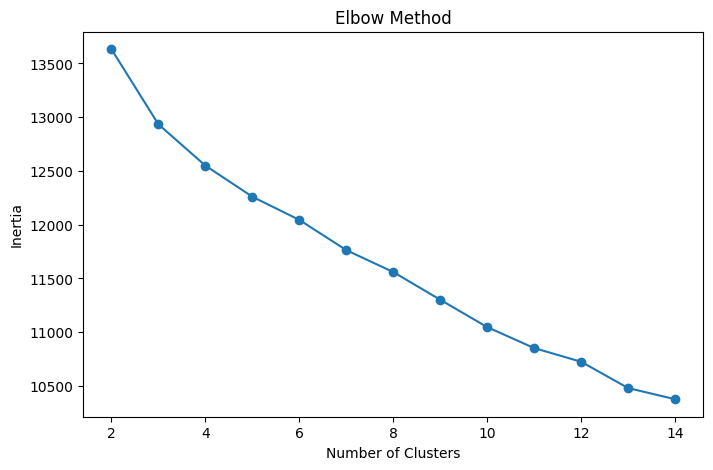

In [149]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    inertia_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [150]:
scores_avg = []

for k in range(2, 15):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = km.fit_predict(X_avg_scaled)
    
    score = silhouette_score(X_avg_scaled, labels)
    scores_avg.append(score)

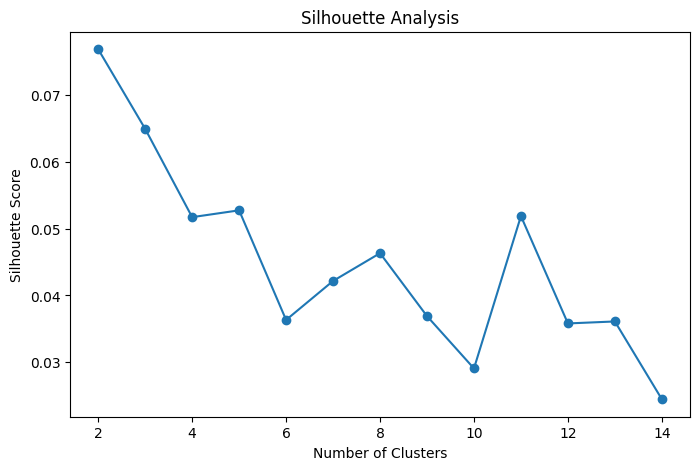

In [151]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,15),
    scores_avg,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

In [152]:
x=3
kmeans = KMeans(
    n_clusters=x,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X_avg_scaled)

df_avg[f"cluster_{x}"] = labels

In [153]:
cluster_avg_summary = (df_avg.drop(columns=fl.metadata_features).groupby(f"cluster_{x}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_avg_summary.transpose())

cluster_3,0,1,2
number_of_seasons,2.125786,2.041322,2.233645
appearances,25.678197,26.938017,27.928349
matchesstarted,25.580713,26.847107,27.785047
minutesplayed,2306.244235,2411.858127,2500.537383
dispossessed_per_touch_zscore,0.013166,-0.018702,0.032602
yellowcards_per90_zscore,-0.175097,0.116249,0.045954
fouls_per90_zscore,-0.102128,0.028852,0.004736
totalduelswon_per90_zscore,-0.280474,0.636056,-0.065245
directredcards_per90_zscore,-0.093448,-0.022038,-0.038151
ballrecovery_per90_zscore,-0.401316,0.575021,0.098144


In [154]:
pca = PCA(n_components=2)

X_avg_pca = pca.fit_transform(X_avg_scaled)

df_avg["PC1"] = X_avg_pca[:,0]
df_avg["PC2"] = X_avg_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"cluster_{x}",
    hover_name='player',         
    hover_data=['team','appearances','minutesplayed'], 
    title=f"Midfielders Avg Clusters (K={x})",
    width=1000,
    height=700
)

fig.show()

In [155]:
df_avg[f"cluster_{x}"].value_counts()

cluster_3
0    159
1    121
2    107
Name: count, dtype: int64

In [156]:
pca = PCA()

X_pca = pca.fit_transform(X_avg_scaled)

cum_var = np.cumsum(pca.explained_variance_ratio_)

In [157]:
var_df = pd.DataFrame({
    "Components": range(1, len(cum_var)+1),
    "Cumulative Variance": cum_var
})

px.line(
    var_df,
    x="Components",
    y="Cumulative Variance",
    title="PCA Explained Variance"
).show()

In [158]:
pca_sizes = range(16,24)

pca_datasets = {}

for n in pca_sizes:
    pca = PCA(n_components=n, random_state=42)
    pca_datasets[n] = pca.fit_transform(X_avg_scaled)

In [159]:
results = []

for n_comp, X_pca in pca_datasets.items():

    for k in range(4, 11):

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = kmeans.fit_predict(X_pca)

        sil = silhouette_score(X_pca, labels)

        results.append(
            {
                "n_components": n_comp,
                "k": k,
                "silhouette": sil
            }
        )

In [160]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    "silhouette",
    ascending=False
).head(20)

,n_components,k,silhouette
7,17,4,0.081246
0,16,4,0.076496
14,18,4,0.076278
8,17,5,0.075089
15,18,5,0.074678
50,23,5,0.072448
35,21,4,0.068087
28,20,4,0.067627
21,19,4,0.067297
36,21,5,0.064213


In [161]:
x=17
pca = PCA(n_components=x)
X_pca = pca.fit_transform(X_avg_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_avg.columns.tolist(),
    columns=[f"PC{i+1}" for i in range(x)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
dispossessed_per_touch_zscore,0.031355,0.077159,-0.076319,-0.089254,0.006777,-0.065389,0.066983,0.076376,0.148221,0.024351,0.447382,-0.279046,-0.130057,0.262314,0.161743,-0.169030,0.255891
yellowcards_per90_zscore,0.105497,0.053315,-0.030868,-0.012793,-0.019280,0.070070,0.351098,0.235660,-0.057648,0.005714,-0.225173,0.110142,0.064745,0.317074,0.078250,-0.338130,0.031739
fouls_per90_zscore,0.080580,0.004852,-0.043505,0.119832,-0.009759,-0.017147,0.360859,0.388648,0.013516,-0.085163,-0.089093,-0.083412,0.166568,-0.066121,-0.110380,-0.057626,0.434726
totalduelswon_per90_zscore,0.308002,-0.020636,-0.255192,-0.109835,0.103892,-0.154175,-0.167336,0.019307,0.022118,-0.168670,-0.016085,-0.094031,0.128316,0.061524,0.190553,-0.051011,-0.070649
directredcards_per90_zscore,0.025446,-0.035044,-0.012472,0.142356,-0.041546,-0.220913,0.333328,0.291810,0.132062,0.047947,-0.210295,-0.154265,-0.080528,0.188158,0.057128,0.379314,-0.059393
ballrecovery_per90_zscore,0.329280,0.117606,-0.114178,0.053540,0.002855,-0.101123,0.166926,-0.231615,-0.068565,0.036083,0.103250,0.187932,0.025379,-0.016211,-0.223631,-0.028975,0.109439
interceptions_per90_zscore,0.055453,-0.024563,-0.040697,0.005874,-0.005222,-0.123649,0.135477,0.228882,0.291638,0.212382,0.408152,0.184599,0.038057,-0.025428,0.085040,0.404525,-0.283790
savedshotsfromoutsidethebox_per90_zscore,0.214462,-0.118822,0.297634,-0.195027,-0.141795,-0.196678,0.028302,-0.031386,-0.116533,0.121097,-0.035101,0.003560,0.017410,-0.044463,-0.033983,-0.007360,0.138607
savesparried_per90_zscore,0.145241,-0.114004,0.316096,-0.179709,-0.177587,-0.013569,-0.098915,0.203827,-0.085131,0.218149,-0.045296,-0.034442,0.102826,0.030750,0.020385,0.032334,0.005448
owngoals_per90_zscore,-0.073932,0.011032,0.042364,-0.109598,-0.055573,-0.074345,-0.067134,0.220626,0.138435,-0.034099,0.164078,0.427363,-0.374063,-0.095506,0.346696,-0.022854,0.194655


In [162]:
for pc in loadings.columns:
    print(f"\n{pc}")
    print(loadings[pc].abs().sort_values(ascending=False).head(10))


PC1
ballrecovery_per90_zscore                   0.329280
totalduelswon_per90_zscore                  0.308002
saves_per90_zscore                          0.283278
aerialduelswon_per90_zscore                 0.274636
clearances_per90_zscore                     0.266463
highclaims_per90_zscore                     0.261144
accuratelongballs_per90_zscore              0.227905
punches_per90_zscore                        0.225670
touches_per90_zscore                        0.216916
savedshotsfromoutsidethebox_per90_zscore    0.214462
Name: PC1, dtype: float64

PC2
accuratepasses_per90_zscore           0.465000
touches_per90_zscore                  0.378903
accuratechippedpasses_per90_zscore    0.378581
goalkicks_per90_zscore                0.314235
possession_lost_per_touch_zscore      0.308441
accuratelongballspercentage_zscore    0.308056
successfulrunsout_per90_zscore        0.189921
errorleadtoshot_per90_zscore          0.135843
expectedassists_per90_zscore          0.131729
xa_per_keyp

In [163]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(x)]
)

In [164]:
results=[]
for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X_pca)

    results.append({
        "k": k,
        "silhouette": silhouette_score(X_pca, labels),
        "inertia": kmeans.inertia_
    })

df_results = pd.DataFrame(results)

In [165]:
px.line(
    df_results,
    x="k",
    y="inertia",
    markers=True,
    title="Elbow Method"
).show()

px.line(
    df_results,
    x="k",
    y="silhouette",
    markers=True,
    title="Silhouette Score"
).show()

In [166]:
cluster=3

kmeans_pca = KMeans(n_clusters=cluster, random_state=42, n_init=20)
df_avg[f'pca_cluster_{cluster}'] = kmeans_pca.fit_predict(X_pca)

cluster_summary = (df_avg.drop(columns=fl.metadata_features+['cluster_3','PC1','PC2',]).groupby(f"pca_cluster_{cluster}").mean())

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(cluster_summary.transpose())

pca_cluster_3,0,1,2
number_of_seasons,2.207921,2.154321,2.032258
appearances,27.801980,25.887860,26.845430
matchesstarted,27.650165,25.798354,26.748656
minutesplayed,2488.724422,2325.511317,2403.154570
dispossessed_per_touch_zscore,0.043051,0.007439,-0.018018
yellowcards_per90_zscore,0.063876,-0.167464,0.095327
fouls_per90_zscore,0.007730,-0.092773,0.016194
totalduelswon_per90_zscore,-0.032621,-0.306279,0.631436
directredcards_per90_zscore,-0.040243,-0.086669,-0.028241
ballrecovery_per90_zscore,0.132856,-0.420750,0.572684


In [167]:
df_avg["PC1"] = X_pca[:,0]
df_avg["PC2"] = X_pca[:,1]

fig = px.scatter(
    df_avg,
    x="PC1",
    y="PC2",
    color=f"pca_cluster_3",
    hover_name='player',         
    hover_data=['team','minutesplayed','number_of_seasons'], 
    title=f"Goalkeepers Clusters (K={cluster})",
    width=1000,
    height=700
)

fig.show()

In [168]:
y=cluster
distances = cdist(X_pca, kmeans_pca.cluster_centers_)

for cluster in range(cluster):

    members = df_avg[df_avg[f"pca_cluster_3"] == cluster]

    member_idx = members.index

    d = distances[member_idx, cluster]

    closest_idx = member_idx[np.argsort(d)[:20]]
    
    print('cluster number-' ,cluster)

    print(df_avg.loc[closest_idx, ["player","team"]])

cluster number- 0
                player                    team
302    Bart Verbruggen  Brighton & Hove Albion
53   Ertuğrul Taşkıran              Alanyaspor
52          Bernd Leno                  Fulham
210       Maarten Paes                AFC Ajax
168        Álex Remiro           Real Sociedad
29       Koen Casteels              Al-Qadsiah
163        André Onana             Trabzonspor
324        Nahuel Noll             Hannover 96
161      Uğurcan Çakır             Galatasaray
183        Luca Zidane                 Granada
275     Germán Parreño  Deportivo de La Coruña
80         Brice Samba           Stade Rennais
76         Rodrigo Rey        CA Independiente
273             Andrew             Gil Vicente
11       Johny Placide                  Bastia
118      Ivan Provedel                   Lazio
198      Bilal Bayazit             Kayserispor
97             Alisson            Liverpool FC
305        Aitor Fraga     Real Sociedad B U21
141      Nahuel Losada                CA L

In [169]:
cluster_mapping = {
    0: "Sweeper Keeper",
    1: "Line Savers",
    2: "Box Commmanders"
}

df_avg['cluster']=df_avg['pca_cluster_3']
df_avg=df_avg.drop(columns=['cluster_3','pca_cluster_3'])
df_avg['cluster_name']=df_avg["cluster"].map(cluster_mapping)

In [170]:
df_ewma=pd.read_csv('../../../data/processed/major_leagues/Goalkeepers/EWMA_Major_Goalkeepers.csv')

In [171]:
import joblib

joblib.dump(scaler, "../../../models/major_leagues/Goalkeepers/scaler.pkl")
joblib.dump(pca, "../../../models/major_leagues/Goalkeepers/pca.pkl")
joblib.dump(kmeans_pca, "../../../models/major_leagues/Goalkeepers/kmeans.pkl")

['../../../models/major_leagues/Goalkeepers/kmeans.pkl']

In [172]:
X_pca_avg = pca.transform(X_avg_scaled)
pca_cols = [f'PC{i+1}' for i in range(17)]
df_coords_avg = pd.DataFrame(X_pca_avg, columns=pca_cols, index=df_avg.index)

df_avg_clustered = pd.concat([df_avg, df_coords_avg], axis=1)
df_avg_clustered['cluster'] = kmeans_pca.labels_
df_avg_clustered['cluster_name'] = df_avg_clustered['cluster'].map(cluster_mapping)

df_avg_clustered.to_csv('../../../data/processed/major_leagues/Goalkeepers/Avg_Major_Goalkeepers_Clustered.csv', index=False)

In [175]:
X_ewma=df_ewma.drop(columns=fl.metadata_features + ['minutesplayed','number_of_seasons','appearances','matchesstarted','offsides_per90_zscore','yellowredcards_per90_zscore','errorleadtogoal_per90_zscore'])

X_scaled_ewma = scaler.transform(X_ewma)
X_pca_ewma = pca.transform(X_scaled_ewma)

pca_cols = [f'PC{i+1}' for i in range(17)]
df_coords_ewma = pd.DataFrame(X_pca_ewma, columns=pca_cols, index=df_ewma.index)

df_ewma_clustered = pd.concat([df_ewma, df_coords_ewma], axis=1)

df_ewma_clustered['cluster']=df_avg['cluster']
df_ewma_clustered['cluster_name']=df_avg['cluster_name']

df_ewma_clustered.to_csv('../../../data/processed/major_leagues/Goalkeepers/EWMA_Major_Goalkeepers_Clustered.csv', index=False)